# 03 - Demonstração: janela de avaliação vs LSTM

Usa o mesmo CSV e os artefatos do **02**. A janela de teste (datas em `scaler.pkl`) foi calibrada no CSV: **100 dias em torno de nov/2022–fev/2023** têm **volatilidade menor** no Mean do que os 100 primeiros dias de 2024, o que torna a comparação real × predito mais estável visualmente.


In [5]:
import sys
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path(".").resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sys.modules.pop("src.features.build_features", None)
sys.modules.pop("src.models.lstm_model", None)
sys.modules.pop("src.models", None)

from src.features.build_features import clean_data, load_raw_data, minmax_transform_clip
from src.models.lstm_model import forecast_sliding_onestep, load_model

DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
MODEL_PATH = MODEL_DIR / "lstm_gas_price.h5"
SCALER_PATH = MODEL_DIR / "scaler.pkl"
CSV_PATH = DATA_DIR / "EthereumGasFee.csv"


In [6]:
bundle = joblib.load(SCALER_PATH)
scaler = bundle["scaler"]
feature_columns = bundle["feature_columns"]
config = bundle["sequence_config"]
target_column = config.target_column
time_col = bundle.get("time_column") or (
    "Date" if "Date" in pd.read_csv(CSV_PATH, nrows=0).columns else "date"
)
fc = bundle.get("forecast", {})
PRED_START = pd.Timestamp(fc.get("pred_start", "2022-11-01"))
FORECAST_DAYS = int(fc.get("forecast_days", 100))
PRED_END_INCLUSIVE = pd.Timestamp(
    fc.get("pred_end_inclusive", str(PRED_START + pd.Timedelta(days=FORECAST_DAYS - 1)))
)

model = load_model(MODEL_PATH)
print("Modelo:", MODEL_PATH)
print("Janela:", PRED_START.date(), "→", PRED_END_INCLUSIVE.date())


Modelo: /Users/levidlima/Development/GasFeesPrediction/models/lstm_gas_price.h5
Janela: 2022-11-01 → 2023-02-08


In [7]:
df = load_raw_data(CSV_PATH)
df = clean_data(df)

col_idx = feature_columns.index(target_column)

df_ord = df.sort_values(time_col, kind="mergesort").reset_index(drop=True)
ts = pd.to_datetime(df_ord[time_col], errors="coerce")
if ts.isna().any():
    raise ValueError("Existem datas inválidas na coluna temporal.")

hit = np.flatnonzero((ts >= PRED_START).to_numpy())
if hit.size == 0:
    raise ValueError(f"Nenhuma data >= {PRED_START.date()} no CSV.")
i0 = int(hit[0])

if i0 < config.window_size:
    raise ValueError(f"Índice inicial {i0} < janela {config.window_size}.")

scaled_all = minmax_transform_clip(
    scaler, df_ord[feature_columns].astype(float)
)

tail_ts = ts.to_numpy()[i0:]
v_end = np.datetime64(pd.Timestamp(PRED_END_INCLUSIVE).to_datetime64())
n_in_period = int(np.searchsorted(tail_ts, v_end, side="right"))
n_eval = min(FORECAST_DAYS, n_in_period, len(df_ord) - i0)
if n_eval <= 0:
    raise ValueError("n_eval <= 0 — confira datas no CSV.")

y_pred_scaled = forecast_sliding_onestep(
    model,
    scaled_all,
    start_index=i0,
    n_steps=n_eval,
    window_size=config.window_size,
)

n_pred = len(y_pred_scaled)
dummy = np.zeros((n_pred, len(feature_columns)))
dummy[:, col_idx] = y_pred_scaled
y_pred = scaler.inverse_transform(dummy)[:, col_idx]

eval_slice = df_ord.iloc[i0 : i0 + n_pred]
y_true = eval_slice[target_column].to_numpy(dtype=np.float64)
dates = eval_slice[time_col].to_numpy()

if n_pred < FORECAST_DAYS:
    print(f"Aviso: apenas {n_pred} dia(s) no intervalo (pedido {FORECAST_DAYS}).")
print(f"Pontos: {n_pred} (sliding 1-pass, alinhados por posição)")


Pontos: 100 (sliding 1-pass, alinhados por posição)


MAE: 2.8052
RMSE: 4.6340


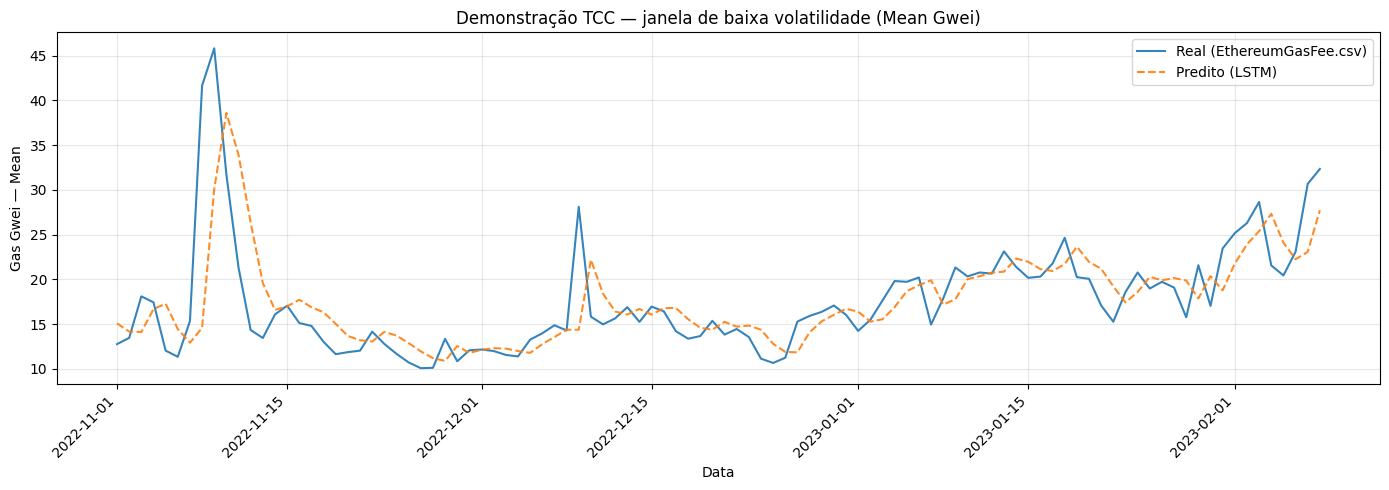

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_true, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, y_true, label="Real (EthereumGasFee.csv)", color="tab:blue", alpha=0.9)
ax.plot(
    dates,
    y_pred,
    label="Predito (LSTM)",
    color="tab:orange",
    alpha=0.9,
    linestyle="--",
)
ax.set_xlabel("Data")
ax.set_ylabel(f"Gas Gwei — {target_column}")
ax.set_title("Demonstração TCC — janela de baixa volatilidade (Mean Gwei)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()
